In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

sns.set(style="whitegrid")

In [16]:
df = pd.read_csv(r"C:\Users\gonza\Desktop\Master\DISA\archive\sentiment-emotion-labelled_Dell_tweets.csv")
df.head()

,Unnamed: 0,Datetime,Tweet Id,Text,Username,sentiment,sentiment_score,emotion,emotion_score
0,0,2022-09-30 23:29:15+00:00,1575991191170342912,@Logitech @apple @Google @Microsoft @Dell @Len...,ManjuSreedaran,neutral,0.853283,anticipation,0.587121
1,1,2022-09-30 21:46:35+00:00,1575965354425131008,@MK_habit_addict @official_stier @MortalKombat...,MiKeMcDnet,neutral,0.519470,joy,0.886913
2,2,2022-09-30 21:18:02+00:00,1575958171423752203,"As @CRN celebrates its 40th anniversary, Bob F...",jfollett,positive,0.763791,joy,0.960347
3,3,2022-09-30 20:05:24+00:00,1575939891485032450,@dell your customer service is horrible especi...,daveccarr,negative,0.954023,anger,0.983203
4,4,2022-09-30 20:03:17+00:00,1575939359160750080,@zacokalo @Dell @DellCares @Dell give the man ...,heycamella,neutral,0.529170,anger,0.776124


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24970 entries, 0 to 24969
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       24970 non-null  int64  
 1   Datetime         24970 non-null  object 
 2   Tweet Id         24970 non-null  int64  
 3   Text             24970 non-null  object 
 4   Username         24970 non-null  object 
 5   sentiment        24970 non-null  object 
 6   sentiment_score  24970 non-null  float64
 7   emotion          24970 non-null  object 
 8   emotion_score    24970 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 1.7+ MB


In [18]:
df.describe(include="all")

,Unnamed: 0,Datetime,Tweet Id,Text,Username,sentiment,sentiment_score,emotion,emotion_score
count,24970.000000,24970,2.497000e+04,24970,24970,24970,24970.000000,24970,24970.000000
unique,NaN,24855,NaN,24639,14773,3,NaN,8,NaN
top,NaN,2022-05-27 19:38:49+00:00,NaN,@Dell That’s very great,johnphillips34,negative,NaN,anger,NaN
freq,NaN,4,NaN,28,334,10556,NaN,7520,NaN
mean,12484.500000,NaN,1.526448e+18,NaN,NaN,NaN,0.782578,NaN,0.819114
std,7208.362447,NaN,2.765398e+16,NaN,NaN,NaN,0.150751,NaN,0.195378
min,0.000000,NaN,1.477082e+18,NaN,NaN,NaN,0.337307,NaN,0.125480
25%,6242.250000,NaN,1.503808e+18,NaN,NaN,NaN,0.664537,NaN,0.722941
50%,12484.500000,NaN,1.524811e+18,NaN,NaN,NaN,0.817950,NaN,0.906610
75%,18726.750000,NaN,1.550124e+18,NaN,NaN,NaN,0.912815,NaN,0.970360


In [19]:
df['sentiment'].value_counts()

sentiment
negative    10556
positive     7366
neutral      7048
Name: count, dtype: int64

In [20]:
df['emotion'].value_counts()

emotion
anger           7520
joy             6326
anticipation    5171
disgust         3000
sadness         1328
optimism        1225
fear             366
surprise          34
Name: count, dtype: int64

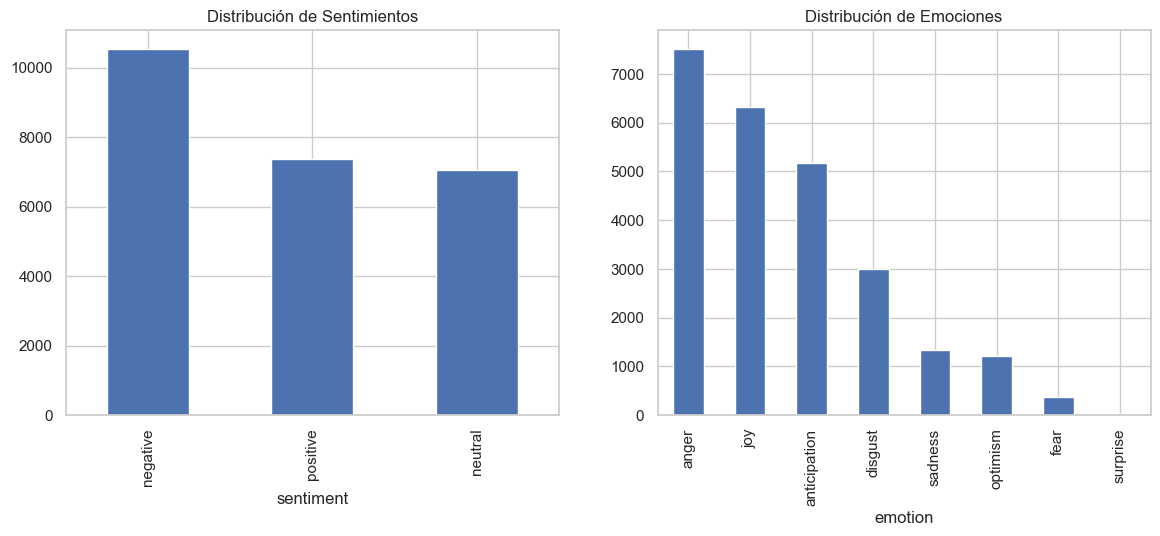

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

df['sentiment'].value_counts().plot(kind='bar', ax=ax[0], title="Distribución de Sentimientos")
df['emotion'].value_counts().plot(kind='bar', ax=ax[1], title="Distribución de Emociones")

plt.show()

In [22]:
df['text_length'] = df['Text'].str.len()
df['text_length'].describe()

count    24970.000000
mean       173.033961
std         88.432032
min         10.000000
25%         95.000000
50%        169.000000
75%        257.000000
max        929.000000
Name: text_length, dtype: float64

In [23]:
df[df['text_length'] < 15].head()

,Unnamed: 0,Datetime,Tweet Id,Text,Username,sentiment,sentiment_score,emotion,emotion_score,text_length
491,491,2022-09-24 19:39:51+00:00,1573759135224836096,@Dell Floppy,dipzdesai,neutral,0.724381,sadness,0.204126,12
708,708,2022-09-21 18:57:15+00:00,1572661249539973123,@Dell HAHAHAHA,ConvergedUsers,neutral,0.481250,joy,0.982242,14
984,984,2022-09-18 22:03:28+00:00,1571620951745339392,Call @Dell,msangela9111,neutral,0.722947,anger,0.365155,10
2089,2089,2022-09-04 05:43:58+00:00,1566301020119973888,@Dell Floppy,naveed93foru,neutral,0.724381,sadness,0.204126,12
2108,2108,2022-09-03 17:00:17+00:00,1566108834241839105,FUCK @Dell,cocolowco,negative,0.933708,anger,0.981187,10


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df['num_hashtags'] = df['Text'].str.count('#')
df['num_mentions'] = df['Text'].str.count('@')

emoji_pattern = r'[\U0001F600-\U0001F64F]'
df['num_emojis'] = df['Text'].str.count(emoji_pattern)

df[['text_length','num_hashtags','num_mentions','num_emojis']].head()

,text_length,num_hashtags,num_mentions,num_emojis
0,275,1,6,0
1,221,1,5,0
2,270,3,8,0
3,204,0,2,0
4,63,0,4,0


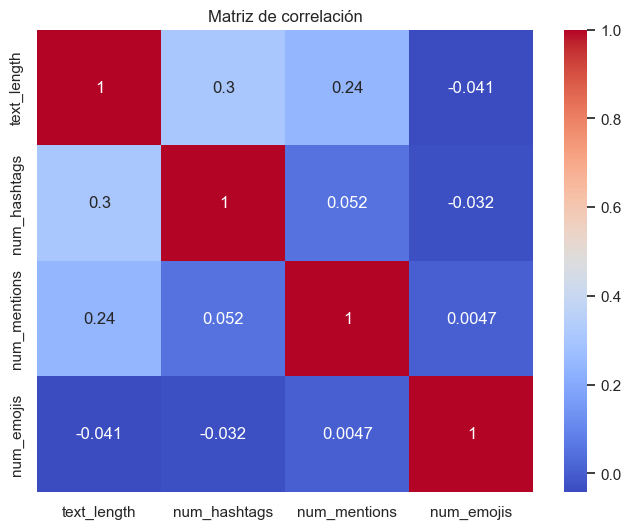

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['text_length','num_hashtags','num_mentions','num_emojis']].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

In [27]:
df.groupby('emotion')['text_length'].mean().sort_values()

emotion
surprise        129.823529
joy             157.691274
disgust         159.067667
sadness         162.884036
anticipation    163.072520
fear            192.224044
anger           194.457713
optimism        203.471020
Name: text_length, dtype: float64

In [28]:
df.groupby('emotion')[['num_hashtags','num_mentions','num_emojis']].mean()

,num_hashtags,num_mentions,num_emojis
emotion,,,
anger,0.282181,2.911835,0.049468
anticipation,0.918971,3.909882,0.017985
disgust,0.320667,3.142333,0.054000
fear,1.040984,2.743169,0.032787
joy,0.909896,3.578881,0.135789
optimism,1.020408,2.791020,0.040000
sadness,0.347892,3.278614,0.178464
surprise,0.000000,3.029412,0.088235
